# 05 — Backtesting

- Загрузка обученных моделей из `models/`
- Transaction costs (0.1% per trade)
- Сигнал: proba ≥ threshold (настраиваемо)
- Метрики: Cumulative Return, Sharpe Ratio, Max Drawdown, Win Rate, Calmar Ratio
- Сравнение со стратегией Buy & Hold
- Walk-forward анализ

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'backend'))

PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR    = ROOT / 'models'
TICKERS       = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'JPM', 'JNJ', 'V']
TRAIN_RATIO   = 0.8
TRANSACTION_COST = 0.001

print(f'Models dir: {MODELS_DIR}')
print(f'Transaction cost: {TRANSACTION_COST:.1%} per trade')

Models dir: /Users/dimabogolaev/EquiSense/models
Transaction cost: 0.1% per trade


## 1. Загрузка моделей

In [2]:
from app.models.baseline_lr import BaselineLRModel
from app.models.model_a import ModelA
from app.models.model_b import ModelB
from app.models.model_c import ModelC
from app.models.model_d import ModelD

model_classes = {
    'baseline_lr': BaselineLRModel,
    'model_a':     ModelA,
    'model_b':     ModelB,
    'model_c':     ModelC,
    'model_d':     ModelD,
}

loaded_models = {}
for name, cls in model_classes.items():
    artifact = MODELS_DIR / f'{name}.joblib'
    if not artifact.exists():
        print(f'[SKIP] {name}: нет артефакта — запустите ноутбук 04')
        continue
    m = cls()
    m.load(artifact)
    loaded_models[name] = m
    print(f'[OK]   {name}')

[OK]   baseline_lr
[OK]   model_a
[OK]   model_b
[OK]   model_c
[OK]   model_d


## 2. Загрузка тестовых данных

In [3]:
def load_ticker(ticker: str) -> pd.DataFrame:
    path = PROCESSED_DIR / ticker / 'technical.parquet'
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_parquet(path)
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)


ticker_data = {}
for ticker in TICKERS:
    df = load_ticker(ticker)
    if not df.empty:
        ticker_data[ticker] = df

print(f'Тикеры с данными: {list(ticker_data.keys())}')

Тикеры с данными: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'JPM', 'JNJ', 'V']


## 3. Движок бэктестинга

In [4]:
def backtest(
    df: pd.DataFrame,
    model,
    threshold: float = 0.55,
    cost: float = TRANSACTION_COST,
) -> pd.DataFrame:
    features = model.feature_set
    avail = [f for f in features if f in df.columns]
    if len(avail) < len(features) * 0.7:
        return pd.DataFrame()

    X = df[avail].fillna(0)
    proba = model.predict_proba(X)[:, 1]

    result = df[['date', 'returns']].copy()
    result['proba']   = proba
    result['signal']  = (proba >= threshold).astype(int)
    result['trade']   = result['signal'].diff().abs().fillna(result['signal'])

    next_return = result['returns'].shift(-1).fillna(0)
    result['gross_return']    = next_return * result['signal']
    result['strategy_return'] = result['gross_return'] - cost * result['trade']
    result['bnh_return']      = result['returns']

    result['cumulative_strategy'] = (1 + result['strategy_return']).cumprod()
    result['cumulative_bnh']      = (1 + result['bnh_return']).cumprod()
    return result.dropna(subset=['returns'])


def compute_metrics(bt: pd.DataFrame) -> dict:
    strat = bt['strategy_return']
    if len(strat) == 0:
        return {}

    total_return  = bt['cumulative_strategy'].iloc[-1] - 1
    bnh_return    = bt['cumulative_bnh'].iloc[-1] - 1
    ann_return    = (1 + total_return) ** (252 / len(strat)) - 1
    sharpe        = (strat.mean() / strat.std() * np.sqrt(252)) if strat.std() > 0 else 0

    cum           = bt['cumulative_strategy']
    max_drawdown  = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar        = ann_return / abs(max_drawdown) if max_drawdown != 0 else 0

    trades        = bt[bt['signal'] == 1]['gross_return']
    win_rate      = (trades > 0).mean() if len(trades) > 0 else 0
    n_trades      = int(bt['signal'].sum())

    return {
        'total_return':  round(total_return, 4),
        'ann_return':    round(ann_return, 4),
        'bnh_return':    round(bnh_return, 4),
        'sharpe':        round(sharpe, 3),
        'max_drawdown':  round(max_drawdown, 4),
        'calmar':        round(calmar, 3),
        'win_rate':      round(win_rate, 4),
        'n_trades':      n_trades,
    }


print('Движок готов.')

Движок готов.


## 4. Запуск по всем тикерам и моделям

In [5]:
all_metrics = []
bt_results  = {}

for ticker, df in ticker_data.items():
    split_idx     = int(len(df) * TRAIN_RATIO)
    test_df       = df.iloc[split_idx:].copy()
    bt_results[ticker] = {}

    for name, model in loaded_models.items():
        bt = backtest(test_df, model)
        if bt.empty:
            continue
        m = compute_metrics(bt)
        m.update({'ticker': ticker, 'model': name})
        all_metrics.append(m)
        bt_results[ticker][name] = bt

if all_metrics:
    metrics_df = pd.DataFrame(all_metrics).set_index(['ticker', 'model'])
    print(metrics_df[['total_return', 'sharpe', 'max_drawdown', 'win_rate', 'n_trades']]
          .round(4).to_string())
else:
    print('[ERROR] Нет результатов. Проверьте наличие данных и артефактов.')

                    total_return  sharpe  max_drawdown  win_rate  n_trades
ticker model                                                              
AAPL   baseline_lr        0.1673   0.987       -0.0508    0.6154        13
       model_a            0.0962   0.548       -0.1217    0.5733        75
       model_b            0.1426   0.741       -0.0893    0.5333        75
       model_c            0.0848   1.513       -0.0172    0.8462        13
       model_d            0.0693   0.432       -0.1112    0.6029        68
MSFT   baseline_lr        0.1113   1.051       -0.0336    0.6923        13
       model_a           -0.1079  -0.787       -0.1540    0.5673       104
       model_b           -0.1335  -0.770       -0.2076    0.5248       101
       model_c            0.0469   1.058       -0.0362    0.8000        10
       model_d           -0.1249  -0.891       -0.1335    0.5648       108
GOOGL  baseline_lr        0.0821   0.831       -0.0161    0.5000         8
       model_a           

## 5. Equity curves

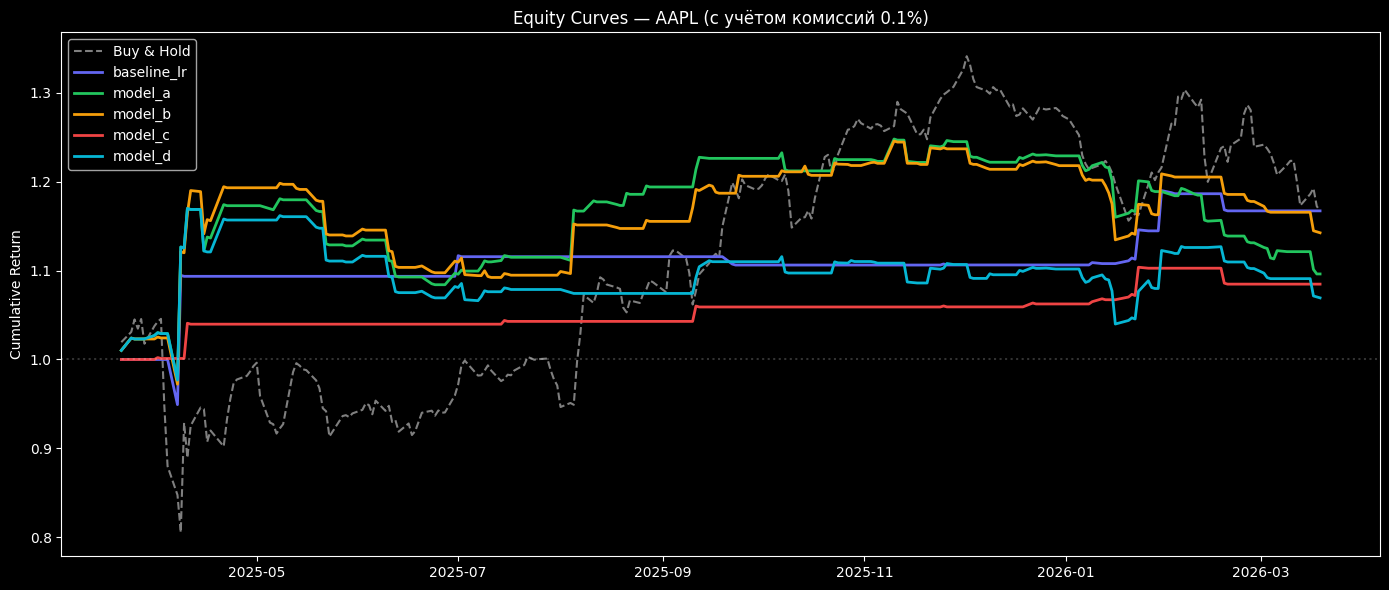

In [6]:
PLOT_TICKER = next((t for t in TICKERS if t in bt_results and bt_results[t]), None)

if PLOT_TICKER:
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ['#6366f1', '#22c55e', '#f59e0b', '#ef4444', '#06b6d4']

    first = next(iter(bt_results[PLOT_TICKER].values()))
    ax.plot(pd.to_datetime(first['date']), first['cumulative_bnh'],
            color='white', linestyle='--', alpha=0.5, label='Buy & Hold', lw=1.5)

    for (name, bt), color in zip(bt_results[PLOT_TICKER].items(), colors):
        ax.plot(pd.to_datetime(bt['date']), bt['cumulative_strategy'],
                color=color, label=name, lw=2)

    ax.axhline(1.0, color='white', linestyle=':', alpha=0.2)
    ax.set_title(f'Equity Curves — {PLOT_TICKER} (с учётом комиссий {TRANSACTION_COST:.1%})')
    ax.set_ylabel('Cumulative Return')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Нет данных для отображения.')

## 6. Средние метрики по всем тикерам

Средние по всем тикерам:
             total_return  ann_return  sharpe  max_drawdown  win_rate  calmar
model                                                                        
baseline_lr        0.1010      0.1018  0.6265       -0.0343    0.5192  4.8025
model_a            0.0655      0.0661  0.1656       -0.1396    0.5389  0.7775
model_b            0.0249      0.0251  0.1687       -0.1515    0.5337  1.3385
model_c            0.0614      0.0620  0.4131       -0.0429    0.6188  1.8419
model_d            0.0622      0.0628  0.2306       -0.1300    0.5565  0.9574


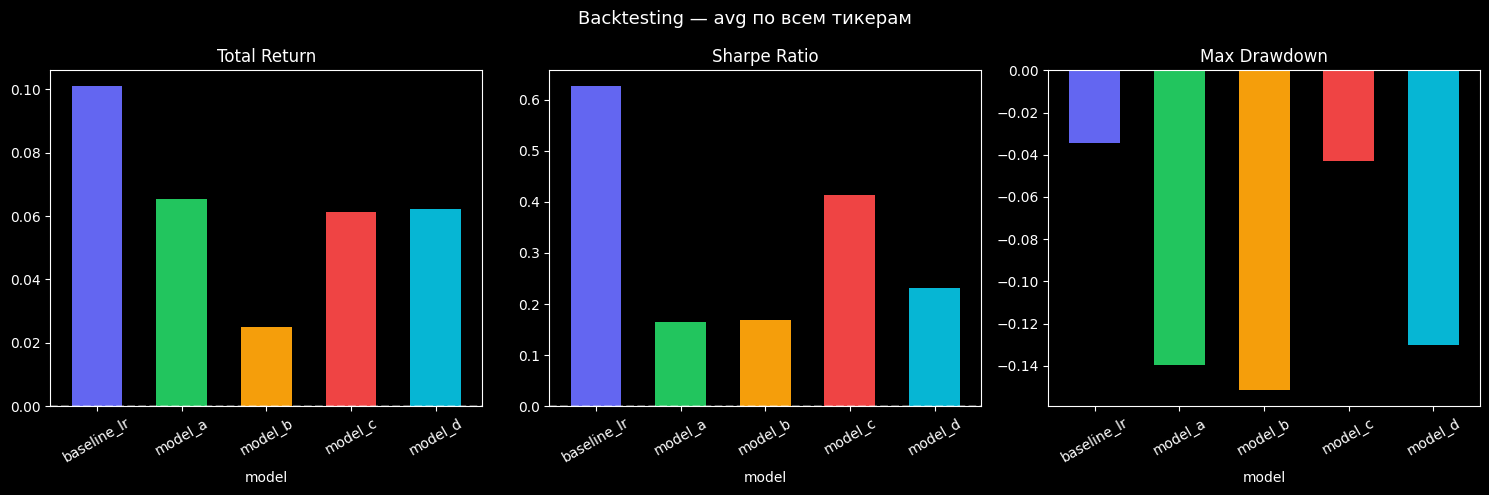

In [7]:
if all_metrics:
    avg = metrics_df.groupby('model')[['total_return', 'ann_return', 'sharpe', 'max_drawdown', 'win_rate', 'calmar']].mean()
    print('Средние по всем тикерам:')
    print(avg.round(4).to_string())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    colors = ['#6366f1', '#22c55e', '#f59e0b', '#ef4444', '#06b6d4']

    avg['total_return'].plot(kind='bar', ax=axes[0], color=colors[:len(avg)], width=0.6)
    axes[0].set_title('Total Return')
    axes[0].axhline(0, color='white', linestyle='--', alpha=0.3)
    axes[0].tick_params(axis='x', rotation=30)

    avg['sharpe'].plot(kind='bar', ax=axes[1], color=colors[:len(avg)], width=0.6)
    axes[1].set_title('Sharpe Ratio')
    axes[1].axhline(0, color='white', linestyle='--', alpha=0.3)
    axes[1].tick_params(axis='x', rotation=30)

    avg['max_drawdown'].plot(kind='bar', ax=axes[2], color=colors[:len(avg)], width=0.6)
    axes[2].set_title('Max Drawdown')
    axes[2].tick_params(axis='x', rotation=30)

    plt.suptitle('Backtesting — avg по всем тикерам', fontsize=13)
    plt.tight_layout()
    plt.show()

## 7. Threshold sensitivity

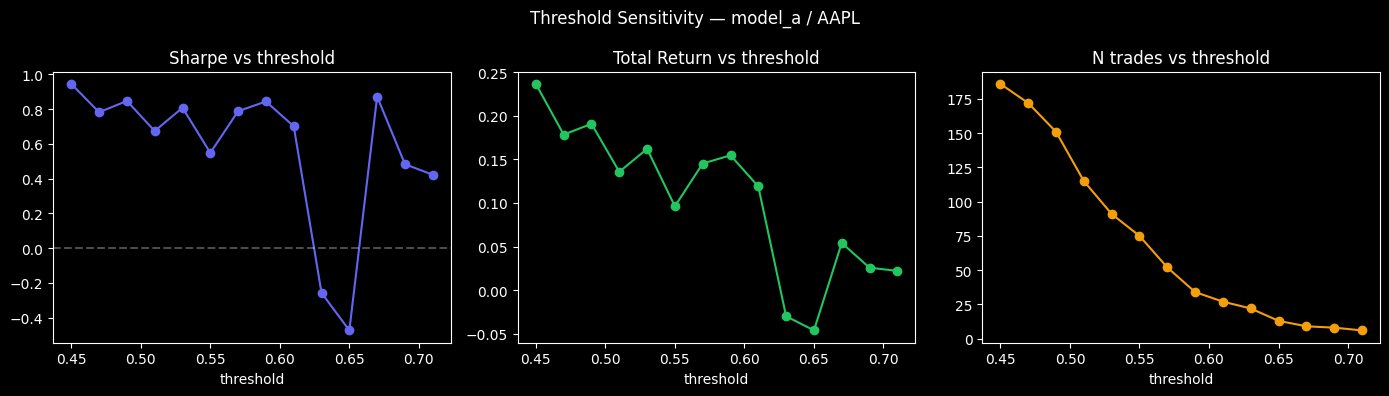

Оптимальный threshold по Sharpe: 0.45


In [8]:
SWEEP_TICKER = next((t for t in TICKERS if t in bt_results and bt_results[t]), None)
SWEEP_MODEL  = 'model_a'

if SWEEP_TICKER and SWEEP_MODEL in loaded_models:
    df_sweep  = ticker_data[SWEEP_TICKER]
    split_idx = int(len(df_sweep) * TRAIN_RATIO)
    test_sw   = df_sweep.iloc[split_idx:].copy()
    model_sw  = loaded_models[SWEEP_MODEL]

    thresholds = np.arange(0.45, 0.72, 0.02)
    th_results = []

    for th in thresholds:
        bt = backtest(test_sw, model_sw, threshold=th)
        if bt.empty:
            continue
        m = compute_metrics(bt)
        m['threshold'] = round(th, 2)
        th_results.append(m)

    if th_results:
        th_df = pd.DataFrame(th_results).set_index('threshold')

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        th_df['sharpe'].plot(ax=axes[0], marker='o', color='#6366f1')
        axes[0].set_title('Sharpe vs threshold')
        axes[0].axhline(0, color='white', linestyle='--', alpha=0.3)

        th_df['total_return'].plot(ax=axes[1], marker='o', color='#22c55e')
        axes[1].set_title('Total Return vs threshold')

        th_df['n_trades'].plot(ax=axes[2], marker='o', color='#f59e0b')
        axes[2].set_title('N trades vs threshold')

        plt.suptitle(f'Threshold Sensitivity — {SWEEP_MODEL} / {SWEEP_TICKER}', fontsize=12)
        plt.tight_layout()
        plt.show()

        best = th_df['sharpe'].idxmax()
        print(f'Оптимальный threshold по Sharpe: {best}')
else:
    print('Нет данных для sweep.')